In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## ETL Phase

In [2]:
# Importing data
spotify_origin = pd.read_csv("C:\\Users\\ihsan\\Data Analysis\\Most Streamed Artists on Spotify\\Data\\Most Streamed Artists on Spotify (17_07_2026) V1.1.csv")

# Making copy of the dataframe to preserve the original copy
spotify = spotify_origin.copy()

# Checking df shape
spotify.shape


(500, 14)

In [3]:
# Previewing df

spotify_origin.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [4]:
# Checking for missing data
spotify.isna().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [5]:
# Fixing Artist Type column name

spotify['Artist Type'] = spotify[' Artist Type']

spotify = spotify.drop(columns=' Artist Type')

# Returning Artist Type to its original place
spotify = spotify[['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', 'Artist Type', 'Debut Year', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)', '% of Solo Streams',
       'Collaborative Streams (in millions)', '% of Collaborative Streams']]

In [6]:
# Checking & previewing dtypes to check wether some column need to be adjusted
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Artist Type                          500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

Going to check the str column to check wether they could be turned into categorical column or using feature engineering by collapsing some values into one categories. Except, Artist Name of course.

In [7]:
spotify['Sex'].value_counts()

Sex
Male      390
Female     88
Mixed      22
Name: count, dtype: int64

In [8]:
spotify['Country of Origin'].value_counts()

Country of Origin
United States          265
United Kingdom          55
Mexico                  27
Canada                  18
Colombia                16
Brazil                  15
India                   13
South Korea             11
Argentina                9
Australia                7
Germany                  7
Spain                    6
Sweden                   5
France                   5
Ireland                  4
Italy                    3
Japan                    2
Scotland                 2
Jamaica                  2
Nigeria                  2
Dominican Republic       2
Norway                   2
Netherlands              2
Barbados                 1
Trinidad and Tobago      1
Panama                   1
Cuba                     1
Morocco                  1
New Zealand              1
Senegal                  1
Chile                    1
South Africa             1
Russia                   1
Venezuela                1
Belgium                  1
DR Congo                 1
Nepal     

In [9]:
spotify['Primary Language'].value_counts()

Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
German          7
French          4
Italian         3
Tamil           2
Urdu            1
Punjabi         1
Name: count, dtype: int64

In [10]:
spotify['Primary Genre'].value_counts()

Primary Genre
Hip-Hop             115
Pop                 102
Rock                 60
Reggaeton            43
R&B                  31
Latin                30
EDM                  22
Regional Mexican     19
K-Pop                11
Filmi                11
Country              10
Alternative           9
Sertanjeo             9
Metal                 8
Folk                  4
Soundtrack            3
Bachata               3
Soul                  3
Reggae                2
Afrobeats             2
Spoken Word           1
Children's Music      1
Nu Metal              1
Name: count, dtype: int64

In [11]:
spotify['Artist Type'].value_counts()

Artist Type
Solo     373
Group    127
Name: count, dtype: int64

Sex and Artist Type is definitely better as a categorical group. But Country of Origin, Primary language and Primary genre need grouping in order to lower its cardinality and to improve its statistical power. First i will group Country of Origin into based on its geographical position and market situation.

In [12]:
# Separate each values into a dictionary
region_mapping = {
    # North American Market (Primarily English-speaking)
    'United States': 'North America', 'Canada': 'North America', 
    
    # Latin America & The Caribbean
    'Mexico': 'Latin America', 'Colombia': 'Latin America', 'Barbados': 'Latin America',
    'Trinidad and Tobago': 'Latin America', 'Cuba': 'Latin America', 'Panama': 'Latin America', 
    'Brazil': 'Latin America', 'Jamaica': 'Latin America', 'Argentina': 'Latin America', 
    'Chile': 'Latin America', 'Venezuela': 'Latin America', 'Dominican Republic': 'Latin America', 
    'Guatemala': 'Latin America',
    
    # European Market
    'United Kingdom': 'Europe', 'Scotland': 'Europe', 'France': 'Europe', 
    'Germany': 'Europe', 'Sweden': 'Europe', 'Norway': 'Europe', 'Netherlands': 'Europe', 
    'Ireland': 'Europe', 'Spain': 'Europe', 'Russia': 'Europe', 'Italy': 'Europe', 
    'Belgium': 'Europe', 'Austria': 'Europe', 'Denmark': 'Europe', 'Iceland': 'Europe',
    
    # Asian Market
    'South Korea': 'Asia', 'India': 'Asia', 'Japan': 'Asia', 
    'Nepal': 'Asia', 'Pakistan': 'Asia', 'Philippines': 'Asia',
    
    # African Market
    'Senegal': 'Africa', 'Morocco': 'Africa', 'Nigeria': 'Africa', 
    'South Africa': 'Africa', 'DR Congo': 'Africa',
    
    # Oceania Market
    'Australia': 'Oceania', 'New Zealand': 'Oceania'
}

# Apply the mapping using the .map() function
spotify['Region'] = spotify['Country of Origin'].map(region_mapping)

# Check the results
print("--- New Regional Distribution ---")
print(spotify['Region'].value_counts())

--- New Regional Distribution ---
Region
North America    283
Europe            96
Latin America     78
Asia              29
Oceania            8
Africa             6
Name: count, dtype: int64


Next, I will group Primary Genre into 7 large category and elaborate on each one below:

1. Pop & Electronic

    Included: Pop, EDM, K-Pop

    The Justification: These genres share massive global crossover appeal and are heavily driven by singles, viral social media trends, and dominant placement on Spotify's flagship playlists (like Today's Top Hits). Their streaming curves often look identical: massive initial spikes followed by a steady plateau.

2. Hip-Hop & R&B (Urban/Rhythmic)

    Included: Hip-Hop, R&B, Soul

    The Justification: These genres share a massive overlapping demographic and dominate the US streaming market. More importantly, artists in these genres heavily collaborate (features and remixes), meaning their stream counts are deeply interconnected through shared listener networks.

3. Rock & Alternative

    Included: Rock, Alternative, Metal, Nu Metal

    The Justification: Rock and Metal listeners have very distinct platform behaviors. They tend to be album-oriented listeners rather than single-oriented, and they demonstrate high long-term loyalty but lower daily rotational streaming compared to Pop or Hip-Hop.

4. Latin & Regional

    Included: Reggaeton, Latin, Regional Mexican, Sertanjeo, Bachata

    The Justification: This represents the fastest-growing streaming market in the world. While "Sertanjeo" is Brazilian and "Regional Mexican" is Mexican, they function identically on a macroeconomic scale: massive, highly localized streaming numbers that frequently cross over into Reggaeton collaborations.

5. Country & Folk

    Included: Country, Folk

    The Justification: These are heavily acoustic, singer-songwriter-driven genres. From a data perspective, they have a highly concentrated domestic audience (primarily North America) and rely heavily on legacy catalog streams rather than just new releases.

6. Media & Soundtrack

    Included: Filmi, Soundtrack, Children's Music

    The Justification: Streams in this category are driven by external media (movies, Bollywood films, cartoons) rather than standard artist fandom. A user streaming a "Children's Music" track is likely a parent playing it on a loop, which creates a completely different data signature than someone streaming a rock band.

7. Global Roots

    Included: Afrobeats, Reggae, Spoken Word

    The Justification: While distinct culturally, these represent niche or emerging global markets in this specific 500-row dataset. Grouping them preserves their status as non-Western-pop genres without discarding them into an anonymous "Other" bucket.

In [13]:
# Define the domain-aware genre mapping
genre_mapping = {
    # Pop & Electronic
    'Pop': 'Pop & Electronic', 'EDM': 'Pop & Electronic', 'K-Pop': 'Pop & Electronic',
    
    # Hip-Hop & R&B
    'Hip-Hop': 'Hip-Hop & R&B', 'R&B': 'Hip-Hop & R&B', 'Soul': 'Hip-Hop & R&B',
    
    # Rock & Alternative
    'Rock': 'Rock & Alternative', 'Alternative': 'Rock & Alternative', 
    'Metal': 'Rock & Alternative', 'Nu Metal': 'Rock & Alternative',
    
    # Latin & Regional
    'Reggaeton': 'Latin & Regional', 'Latin': 'Latin & Regional', 
    'Regional Mexican': 'Latin & Regional', 'Sertanjeo': 'Latin & Regional', 
    'Bachata': 'Latin & Regional',
    
    # Country & Folk
    'Country': 'Country & Folk', 'Folk': 'Country & Folk',
    
    # Media & Soundtrack
    'Filmi': 'Media & Soundtrack', 'Soundtrack': 'Media & Soundtrack', 
    "Children's Music": 'Media & Soundtrack',
    
    # Global Roots
    'Afrobeats': 'Global Roots', 'Reggae': 'Global Roots', 'Spoken Word': 'Global Roots'
}

# Apply the mapping
spotify['Collapsed Genre'] = spotify['Primary Genre'].map(genre_mapping)

# Check the results
print("--- New Macro-Genre Distribution ---")
print(spotify['Collapsed Genre'].value_counts())

--- New Macro-Genre Distribution ---
Collapsed Genre
Hip-Hop & R&B         149
Pop & Electronic      135
Latin & Regional      104
Rock & Alternative     78
Media & Soundtrack     15
Country & Folk         14
Global Roots            5
Name: count, dtype: int64


Next, I will collapse the value in Primary Language into Other if they are less than 1% of the data. Thus, if the value counts is below 5, the data will be grouped into others

In [14]:
# Define the columns you want to process and the threshold

columns_to_collapse = ['Primary Language']
threshold = 0.01

# Loop through each specified column
for col in columns_to_collapse:
    
    # Calculate frequencies for the current column
    frequencies = spotify[col].value_counts(normalize=True)
    
    # Identify categories that fall below the 1% threshold
    rare_categories = frequencies[frequencies < threshold].index
    
    # Replace the rare categories with 'Other'
    spotify[col] = spotify[col].replace(rare_categories, 'Other')
    
# Check the results
print("--- New Language Distribution ---")
print(spotify['Primary Language'].value_counts())

--- New Language Distribution ---
Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
Other          11
German          7
Name: count, dtype: int64


Finally, turn all of those column into categorical dtypes

In [15]:
# Changing into categorical dytpe 
spotify['Sex'] = spotify['Sex'].astype('category')
spotify['Primary Language'] = spotify['Primary Language'].astype('category')
spotify['Genre'] = spotify['Primary Genre'].astype('category')
spotify['Region'] = spotify['Country of Origin'].astype('category')
spotify['Artist Type'] = spotify['Artist Type'].astype('category')

# Checking
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Artist Name                          500 non-null    object  
 1   Sex                                  500 non-null    category
 2   Country of Origin                    500 non-null    object  
 3   Primary Language                     500 non-null    category
 4   Primary Genre                        500 non-null    object  
 5   Artist Type                          500 non-null    category
 6   Debut Year                           500 non-null    int64   
 7   Total Streams (in millions)          500 non-null    float64 
 8   Lead Streams (in millions)           500 non-null    float64 
 9   Feature Streams (in millions)        500 non-null    float64 
 10  Solo Streams (in millions)           500 non-null    float64 
 11  % of Solo Streams  

In [16]:
#Subsetting the data into final df to be processed in the next step
sub_spotify = spotify[['Artist Name', 'Sex', 'Region', 'Primary Language', 'Collapsed Genre', 'Artist Type', 'Debut Year', 'Total Streams (in millions)',\
                      'Lead Streams (in millions)', 'Feature Streams (in millions)', 'Solo Streams (in millions)', '% of Solo Streams',\
                      'Collaborative Streams (in millions)', '% of Collaborative Streams']]

# Saving externally for documentation
sub_spotify.to_csv('C:\\Users\\ihsan\\Data Analysis\\Most Streamed Artists on Spotify\\Data\\Sub_spotify.csv', index=False)

# Checking
sub_spotify.head()

,Artist Name,Sex,Region,Primary Language,Collapsed Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop & R&B,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop & Electronic,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Latin & Regional,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,Hip-Hop & R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop & Electronic,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


Much better!

## EDA Phase

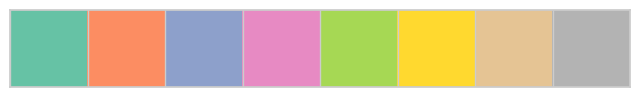

In [17]:
# Apply the theme
palette = sns.color_palette(palette='Set2')
sns.set_theme(style="whitegrid", palette=palette, font="sans-serif")
sns.palplot(palette)
plt.show()

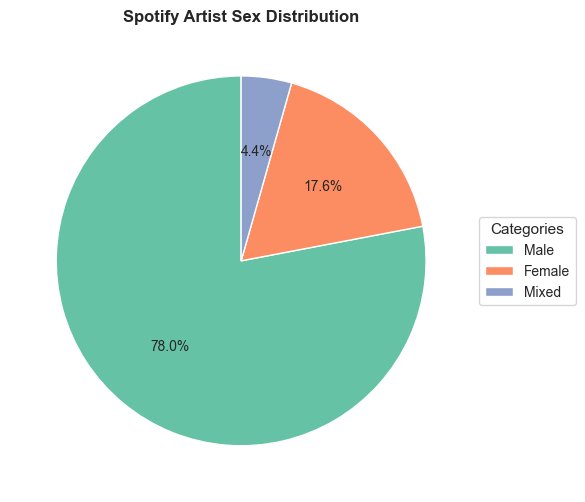

In [18]:
# Making pie chart to visualize the artist sex distribution

# Preparing the value counts
class_counts = spotify['Sex'].value_counts()

labels = class_counts.index
values = class_counts.values

# Create a custom formatting function to turn the value into percentage
def autopct(pct):
    # Calculate the raw count from the percentage
    total = sum(values)
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%'

# Plot the pie chart using the custom function
plt.figure(figsize=(6, 6))
plt.pie(
    values,
    autopct=autopct,
    startangle=90, 
    textprops={'fontsize': 10}
)

# Customizing the legend
plt.legend(labels, 
           title="Categories", 
           loc="center left", 
           bbox_to_anchor=(1, 0.5), #putting the legend on the right side of the chart
           fontsize=10, 
           title_fontsize=11)

plt.title('Spotify Artist Sex Distribution', fontweight="bold")
plt.tight_layout()
plt.show()

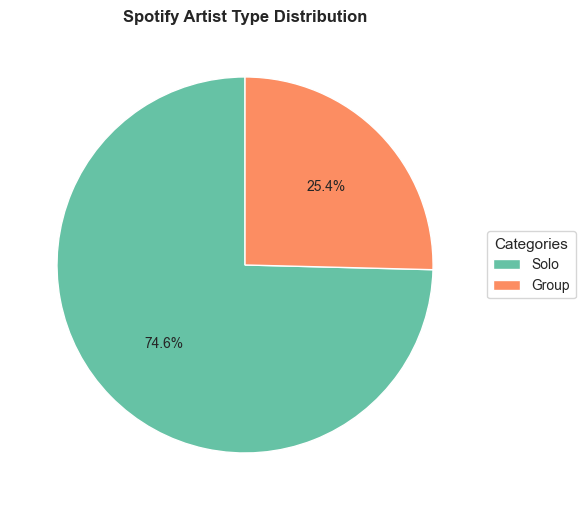

In [19]:
# Making pie chart to visualize the artist type distribution

# Preparing the value counts
class_counts = spotify['Artist Type'].value_counts()

labels = class_counts.index
values = class_counts.values

# Create a custom formatting function to turn the value into percentage
def autopct(pct):
    # Calculate the raw count from the percentage
    total = sum(values)
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%'

# Plot the pie chart using the custom function
plt.figure(figsize=(6, 6))
plt.pie(
    values,
    autopct=autopct,
    startangle=90, 
    textprops={'fontsize': 10}
)

# Customizing the legend
plt.legend(labels, 
           title="Categories", 
           loc="center left", 
           bbox_to_anchor=(1, 0.5), #putting the legend on the right side of the chart
           fontsize=10, 
           title_fontsize=11)

plt.title('Spotify Artist Type Distribution', fontweight="bold")
plt.tight_layout()
plt.show()

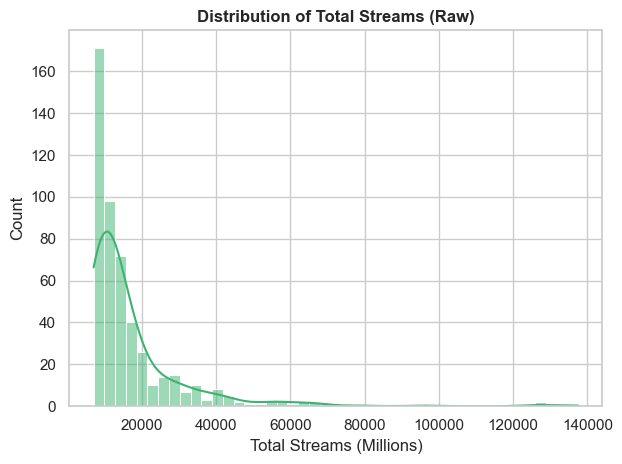

In [20]:
# Distribution of Total Streams
sns.histplot(sub_spotify['Total Streams (in millions)'], kde=True, color='mediumseagreen')
plt.title('Distribution of Total Streams (Raw)',  fontweight="bold")
plt.xlabel('Total Streams (Millions)')
plt.tight_layout()
plt.show()

It seems like the total stream data is skewed to the right. The long tail on the right suggests that there are a few outliers with very high values. A logarithmic scale can help to compress these large values, making the distribution more symmetric and easier to visualize. But it would also mean the data would be harder to interpret and internalized.

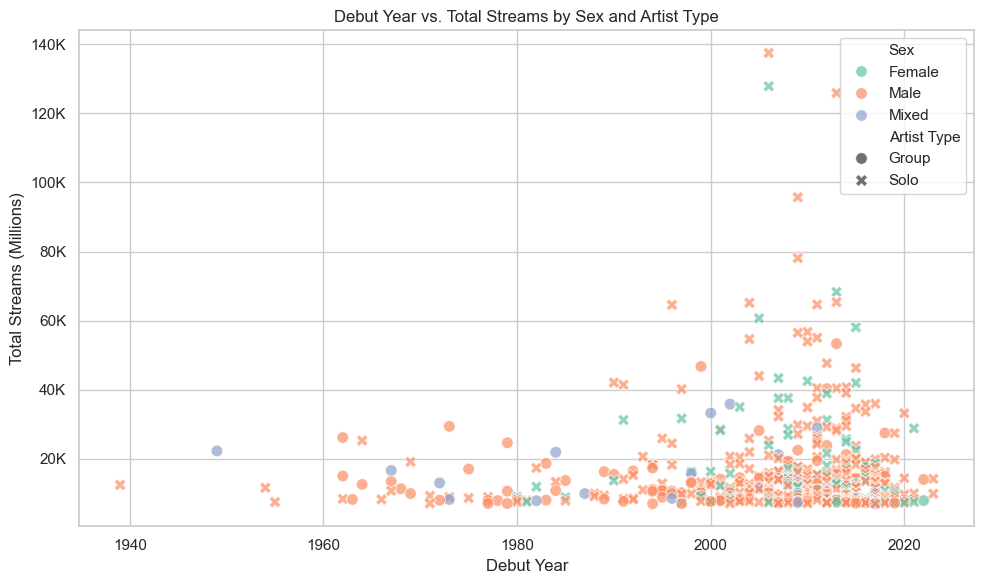

In [21]:
# Debut Year vs Total Streams by Sex / Artist Type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sub_spotify, x='Debut Year', y='Total Streams (in millions)', hue='Sex', style='Artist Type', alpha=0.7, s=70)
plt.title('Debut Year vs. Total Streams by Sex and Artist Type')
plt.xlabel('Debut Year')
plt.ylabel('Total Streams (Millions)')
plt.yticks([20000, 40000, 60000, 80000, 100000, 120000, 140000], ['20K', '40K', '60K', '80K', '100K', '120K', '140K'])
plt.tight_layout()
plt.show()

Chart above is basically summarizing the other three charts

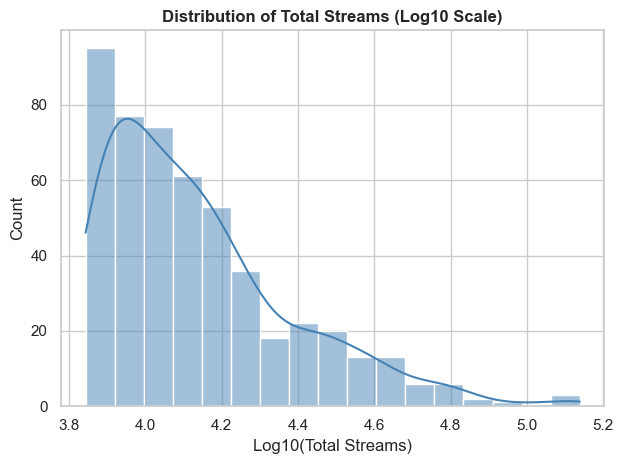

In [22]:
sns.histplot(np.log10(sub_spotify['Total Streams (in millions)']), kde=True, color='steelblue')
plt.title('Distribution of Total Streams (Log10 Scale)',  fontweight="bold")
plt.xlabel('Log10(Total Streams)')
plt.tight_layout()
plt.show()

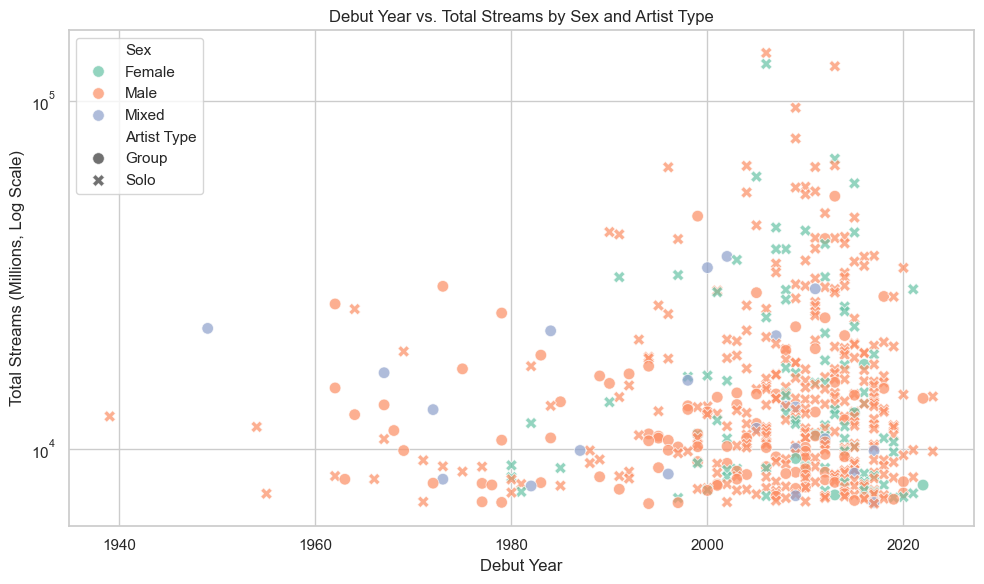

In [23]:
# Debut Year vs Total Streams by Sex / Artist Type (scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sub_spotify, x='Debut Year', y='Total Streams (in millions)', hue='Sex', style='Artist Type', alpha=0.7, s=70)
plt.title('Debut Year vs. Total Streams by Sex and Artist Type')
plt.yscale('log')
plt.xlabel('Debut Year')
plt.ylabel('Total Streams (Millions, Log Scale)')
plt.tight_layout()
plt.show()

Yup, now the data is also easier to view. And it seems like the number of debuting male solo artist also increased exponentially over the years. Which is why male and solo artist is dominant in this dataset.

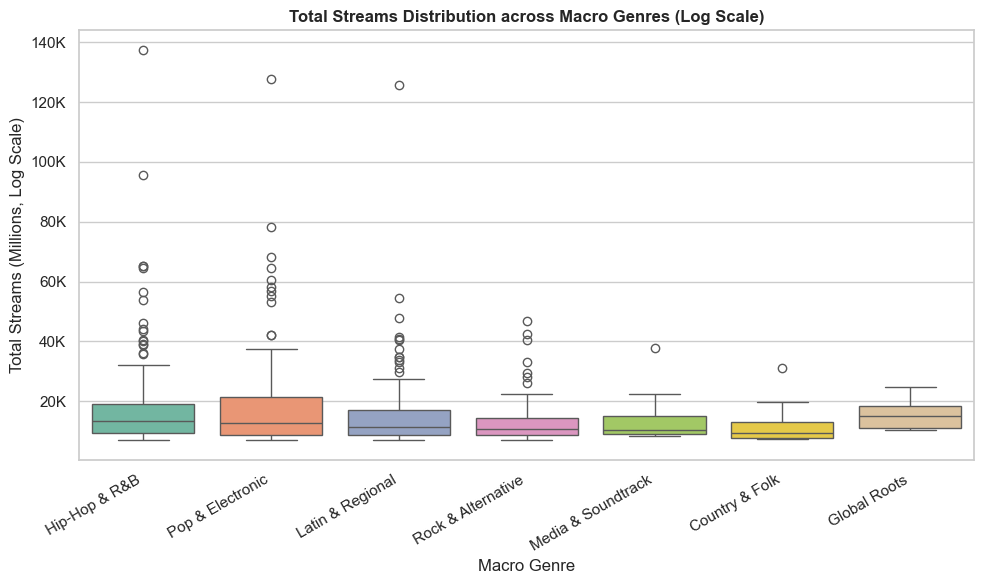

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=sub_spotify, x='Collapsed Genre', hue='Collapsed Genre', y='Total Streams (in millions)')
plt.xticks(rotation=30, ha='right')
plt.title('Total Streams Distribution across Macro Genres (Log Scale)', fontweight="bold")
plt.ylabel('Total Streams (Millions, Log Scale)')
plt.yticks([20000, 40000, 60000, 80000, 100000, 120000, 140000], ['20K', '40K', '60K', '80K', '100K', '120K', '140K'])
plt.xlabel('Macro Genre')
plt.tight_layout()
plt.show()

In [25]:
# 2. Define the IQR Outlier formula
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate the bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return the count of values outside the bounds
    return ((series < lower_bound) | (series > upper_bound)).sum()

# 3. Apply the function to each genre
outliers = sub_spotify.groupby('Collapsed Genre')['Total Streams (in millions)'].apply(count_outliers)
print("--- Number of outlier ---")
print(outliers)

--- Number of outlier ---
Collapsed Genre
Country & Folk         1
Global Roots           0
Hip-Hop & R&B         16
Latin & Regional      13
Media & Soundtrack     1
Pop & Electronic      11
Rock & Alternative     7
Name: Total Streams (in millions), dtype: int64


Since the data is made in 17/07/2026, it is quite normal for Hip-Hop & R&B to have a lot more outlier. Because it is one of the most famous genre today & it is pretty common to have a outlier in this case. Also another thing to note, all of the outlier are an upper outlier. Which mean, they are more famous then other musician in the same genre.

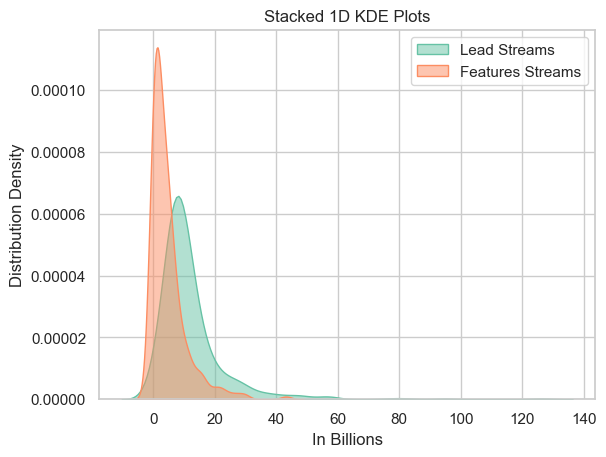

In [26]:

sns.kdeplot(data=sub_spotify, x="Lead Streams (in millions)", fill=True, label="Lead Streams", alpha=0.5)
sns.kdeplot(data=sub_spotify, x="Feature Streams (in millions)", fill=True, label="Features Streams", alpha=0.5)

plt.xlabel("In Billions")
plt.xticks([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000], ['0', '20', '40', '60', '80', '100', '120', '140'])
plt.ylabel("Distribution Density")
plt.title("Stacked 1D KDE Plots")
plt.legend()

plt.show()

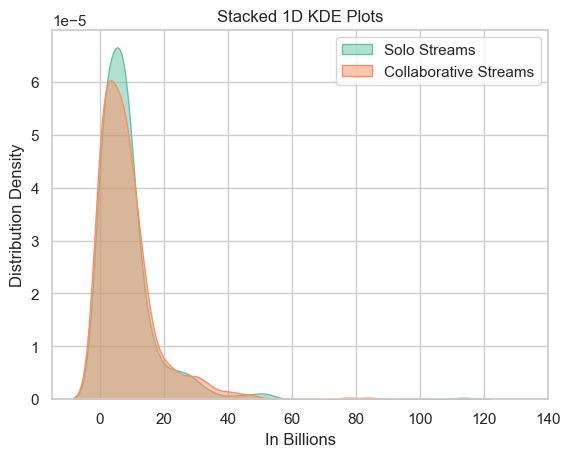

In [27]:

sns.kdeplot(data=sub_spotify, x="Solo Streams (in millions)", fill=True, label="Solo Streams", alpha=0.5)
sns.kdeplot(data=sub_spotify, x="Collaborative Streams (in millions)", fill=True, label="Collaborative Streams", alpha=0.5)

plt.xlabel("In Billions")
plt.xticks([0, 20000, 40000, 60000, 80000, 100000, 120000, 140000], ['0', '20', '40', '60', '80', '100', '120', '140'])
plt.ylabel("Distribution Density")
plt.title("Stacked 1D KDE Plots")
plt.legend()

plt.show()

In [28]:
#need to explain the kde plot
